# ML Climate Zones Tutorial - Evaluation
* Author: Stephen Haddad
* Affiliation: UK Met Office
* History: 1.0
* Last update: 2026-03-16
* © British Crown Copyright 2017-2026, Met Office. Please see LICENSE.md for license details.

## Overview of the broad topic covered

In previous notebooks we have trained a few ML models to predict the climate zone of a land point on earth from the climate means for that point. In this notebook we will dig deeper into how well our trained models are performing and consider different ways to measure that.


### Prerequisites 
- Same as previous notebooks
- Have completed model training pipeline notebook


### Learning outcomes from completing the notebook
- Load model and data and make predictions
- Calculate a range of metrics for a classification problem
- Break down the results by target class and other data subsets to gain insight into when the model performs better or worse.


## Tutorial - Model Evaluation
To determine whether the algorithm is performing well, we need to measure the performance in some way. For supervised learning, metrics are divided by the two key types of problem: regression and classification. Whichever sort of algorithm you're using, getting good results depends on measuring the right thing that best reflects the real world impact, business need or physical reality of the system being studied. Choosing the wrong metric might result in a trained algorithm that seemingly performs well in development, but isn't actually that useful in the real world.

We're dealing with a classification problem here, so we will use classification relevant metrics.
The obvious metric to use is accuracy i.e. how many predictions did we get right? As we will see, this  usually does represent the way want the algorithm to perform. Obviously we want all the predictions to be correct, but generally, some will be wrong. Depending on the impact of incorrect predictions, we may wish penalise certain mistakes more or less. Different sorts of metrics allow us to do that.
    
A common starting point is precision and recall. This is frequently confusing, and the [wikipedia page](https://en.wikipedia.org/wiki/Precision_and_recall) has numerous useful explanations and diagrams. 


* **Precision** is the portion of data points predicted as being in a class that are actually in that class.
  * In other words, `Precision = P( true positive / classified as positive)`
* **Recall** in the proportion of data points that are in a specific class in reality that are predicted as being in that class.
   * In other words, `Recall = P( correctly classified / total observed positive)`

In the diagram below the events in the circle are all the predicted events (eg, predicted rotors to happen). The left side of the square are the total number of actual events that occurred. 

![Precision and recall](https://raw.githubusercontent.com/MetOffice/ml_weather_tutorial/refs/heads/main/images/Precisionrecall.svg)

Graphic taken from Wikipedia

### Import libraries

In [1]:
import pathlib
import os
import datetime
import json
import pickle

In [25]:
import pandas
import numpy

In [54]:
import matplotlib.pyplot

In [3]:
import sklearn
import sklearn.preprocessing
import sklearn.tree
import torch

In [4]:
with open ('config.json','r') as tutorial_config:
    tutorial_config = json.load(tutorial_config)
tutorial_config

{'platform': 'jasmin',
 'default_dirs': {'mo_linux': '/data/users/dscop/ml_tutorial/',
  'jasmin': '/gws/nopw/j04/mohc_shared/dscop/'},
 'random_seed': 12345,
 'climate_subgroups': {'non-land': 'None',
  'Af': 'Tropical, rainforest',
  'Am': 'Tropical, monsoon',
  'Aw': 'Tropical, savannah',
  'BWh': 'Arid, desert, hot',
  'BWk': 'Arid, desert, cold',
  'BSh': 'Arid, steppe, hot',
  'BSk': 'Arid, steppe, cold',
  'Csa': 'Temperate, dry summer, hot summer',
  'Csb': 'Temperate, dry summer, warm summer',
  'Csc': 'Temperate, dry summer, cold summer',
  'Cwa': 'Temperate, dry winter, hot summer',
  'Cwb': 'Temperate, dry winter, warm summer',
  'Cwc': 'Temperate, dry winter, cold summer',
  'Cfa': 'Temperate, no dry season, hot summer',
  'Cfb': 'Temperate, no dry season, warm summer',
  'Cfc': 'Temperate, no dry season, cold summer',
  'Dsa': 'Cold, dry summer, hot summer',
  'Dsb': 'Cold, dry summer, warm summer',
  'Dsc': 'Cold, dry summer, cold summer',
  'Dsd': 'Cold, dry summer, ver

In [5]:
def get_platform_dir(select_platform, config):
    try:
        root_path = pathlib.Path(config['default_dirs'][select_platform]) / 'climate_zones'
    except KeyError:
        root_path = pathlib.Path(os.environ['HOME']) / 'climate_zones'
    return root_path

In [6]:
current_platform = tutorial_config['platform']

In [7]:
root_data_dir = get_platform_dir(current_platform, tutorial_config)

print(root_data_dir.is_dir())
root_data_dir

True


PosixPath('/gws/nopw/j04/mohc_shared/dscop/climate_zones')

In [8]:
ml_ready_dir = root_data_dir / 'ml_ready'
print(ml_ready_dir.is_dir())
ml_ready_dir

True


PosixPath('/gws/nopw/j04/mohc_shared/dscop/climate_zones/ml_ready')

In [9]:
resolutions_dict = {float(k1): v1 for k1,v1 in tutorial_config['resolutions_names'].items()}

dataset_prefix_dict = tutorial_config['dataset_prefix']

format_str = 'nc'
historic_scenario_str = 'historic'

future_scenario_list = tutorial_config['future_scenarios']
historic_scenario_list = tutorial_config['historic_scenarios']

time_periods = { 
    (1901,1930): historic_scenario_list, 
    (1931,1960): historic_scenario_list,
    (1961,1990): historic_scenario_list,
    (1991,2020): historic_scenario_list,
    (2041,2070): future_scenario_list,
    (2071,2099): future_scenario_list,
}


In [10]:
fname_template = tutorial_config['fname_template']
time_dir_template = tutorial_config['time_dir_template']
ml_ready_fname_template = tutorial_config['csv_out_template']

### Load data for inference

In [11]:
current_res = 1.0

In [12]:
mlready_data_path = ml_ready_dir / ml_ready_fname_template.format(resolution=resolutions_dict[current_res])
print(mlready_data_path.is_file())
mlready_data_path

True


PosixPath('/gws/nopw/j04/mohc_shared/dscop/climate_zones/ml_ready/climate_zones_1p0.csv')

In [13]:
zones_df = pandas.read_csv(mlready_data_path)

In [14]:
zones_df

,lat,lon,precipitation_1.0_mean,precipitation_2.0_mean,precipitation_3.0_mean,precipitation_4.0_mean,precipitation_5.0_mean,precipitation_6.0_mean,precipitation_7.0_mean,precipitation_8.0_mean,...,air_temperature_10.0_std,air_temperature_11.0_std,air_temperature_12.0_std,kg_class,kg_confidence,period_start,period_end,scenario,climate_group,climate_subgroup
0,83.5,-38.5,12.1250,8.2500,8.9375,21.8750,15.5000,29.8750,35.8750,46.1250,...,2.5625,3.3125,3.6250,29.0,83.0,1901,1930,historic,E,E
1,83.5,-37.5,10.8750,8.1250,8.6250,19.6250,13.8125,26.8750,32.0625,42.0000,...,3.0000,3.8125,4.1250,30.0,86.0,1901,1930,historic,E,E
2,83.5,-36.5,9.9375,8.4375,8.8125,18.1250,12.3750,23.6875,28.5000,37.8125,...,2.5000,3.1875,3.4375,30.0,84.0,1901,1930,historic,E,E
3,83.5,-35.5,10.0000,8.8750,9.0625,17.6250,12.0000,22.4375,26.9375,35.9375,...,2.3750,3.1250,3.4375,30.0,86.0,1901,1930,historic,E,E
4,83.5,-34.5,10.1250,9.1875,9.4375,16.7500,11.3750,20.6250,24.9375,33.3750,...,1.9375,2.5000,2.8750,30.0,76.0,1901,1930,historic,E,E
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
406489,-89.5,175.5,4.0000,4.5625,6.6250,7.0000,7.1875,5.7500,5.6250,8.3125,...,1.1250,1.1250,1.4375,30.0,100.0,2071,2099,ssp585,E,E
406490,-89.5,176.5,4.0000,4.5625,6.6875,7.0625,7.2500,5.8125,5.6250,8.4375,...,1.1250,1.1250,1.4375,30.0,100.0,2071,2099,ssp585,E,E
406491,-89.5,177.5,4.0625,4.6250,6.6875,7.1250,7.3125,5.8125,5.6875,8.7500,...,1.1250,1.1250,1.4375,30.0,100.0,2071,2099,ssp585,E,E
406492,-89.5,178.5,4.0625,4.6250,6.6875,7.1250,7.3125,5.8125,5.6875,9.0000,...,1.1250,1.1875,1.4375,30.0,100.0,2071,2099,ssp585,E,E


In [15]:
predictors_dict = {
    'precip_mean': [c1 for c1 in zones_df.columns if 'precipitation' in c1 and 'mean' in c1],
    'precip_std': [c1 for c1 in zones_df.columns if 'precipitation' in c1 and 'std' in c1],
    'temp_mean': [c1 for c1 in zones_df.columns if 'air_temperature' in c1 and 'mean' in c1],
    'temp_std': [c1 for c1 in zones_df.columns if 'air_temperature' in c1 and 'std' in c1],
}


In [16]:
predictors = predictors_dict['precip_mean'] + predictors_dict['temp_mean']
predictors

['precipitation_1.0_mean',
 'precipitation_2.0_mean',
 'precipitation_3.0_mean',
 'precipitation_4.0_mean',
 'precipitation_5.0_mean',
 'precipitation_6.0_mean',
 'precipitation_7.0_mean',
 'precipitation_8.0_mean',
 'precipitation_9.0_mean',
 'precipitation_10.0_mean',
 'precipitation_11.0_mean',
 'precipitation_12.0_mean',
 'air_temperature_1.0_mean',
 'air_temperature_2.0_mean',
 'air_temperature_3.0_mean',
 'air_temperature_4.0_mean',
 'air_temperature_5.0_mean',
 'air_temperature_6.0_mean',
 'air_temperature_7.0_mean',
 'air_temperature_8.0_mean',
 'air_temperature_9.0_mean',
 'air_temperature_10.0_mean',
 'air_temperature_11.0_mean',
 'air_temperature_12.0_mean']

We have two options for the target. We have the full 30 class climate subgroups of the Koppen-Geiger classification data from the original dataset. We also have the processed five class climate group target, which presents an easier target for our classification algorithm to predict.

In [17]:
target_var = 'climate_group' # 5 classes
# target_var = 'climate_subgroup # 30 classes


By setting a random seed, we are ensuring that we get the train/val/test split in each of the notebooks.

In [18]:
random_seed = tutorial_config['random_seed']

In [19]:
test_frac = 0.1
val_frac = 0.1
val_frac_sub = (val_frac / (1.0-test_frac) )

In [20]:
test_df = zones_df.groupby(['period_start','scenario']).sample(frac=test_frac, random_state=random_seed)
remain_df = zones_df.drop(test_df.index)

In [21]:
val_df = remain_df.groupby(['period_start','scenario']).sample(frac=val_frac_sub, random_state=random_seed)
train_df = remain_df.drop(val_df.index)


We now load in the stats for normalising data that were calculated on the train set so we can apply the same transforms to the data we are using for inference.

In [23]:
with open('stats.json','r') as stats_file:
    stats_dict = json.load(stats_file)


In [27]:
input_scaler = sklearn.preprocessing.StandardScaler()
input_scaler.mean_ = numpy.array(stats_dict['input_mean'])
input_scaler.scale_ = numpy.array(stats_dict['input_scale'])


In [28]:
input_scaler.mean_

array([45.60325551, 42.46725422, 47.28701423, 45.44816516, 49.1452389 ,
       53.91752074, 62.3702213 , 62.65474845, 53.71220722, 49.2228401 ,
       44.65585602, 45.3735071 , -4.92011775, -6.30046417, -6.32297451,
       -4.1419975 , -1.26653221,  1.41542957,  2.18593791,  1.4822868 ,
       -0.36148434, -2.10336602, -3.25530913, -3.90286522])

In [29]:
X_train = input_scaler.transform(train_df[predictors])
X_val = input_scaler.transform(val_df[predictors])
X_test = input_scaler.transform(test_df[predictors])

/home/users/shaddad/mohc_shared/users/shaddad/venv/ai4c_nb_cpu/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/home/users/shaddad/mohc_shared/users/shaddad/venv/ai4c_nb_cpu/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/home/users/shaddad/mohc_shared/users/shaddad/venv/ai4c_nb_cpu/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [30]:
train_df[[target_var]].value_counts()

climate_group
E                116146
D                 80766
B                 60790
A                 40252
C                 27252
Name: count, dtype: int64

In [31]:
target_encoder = sklearn.preprocessing.LabelEncoder()
target_encoder.classes_ = numpy.array(stats_dict['target_classes'],dtype='object')

In [32]:
y_train = target_encoder.transform(train_df[target_var])
y_val = target_encoder.transform(val_df[target_var])
y_test = target_encoder.transform(test_df[target_var])


In [33]:
algorithm_name = 'decision_tree'

In [34]:
%%time
load_pretrain=True
if load_pretrain:
    with open(f'{algorithm_name}.pkl', 'rb') as f:
        dt_clf = pickle.load(f)
else:
    dt_opts = {'max_depth':10, 'min_samples_leaf': 2, 'min_samples_split': 5}
    dt_clf = sklearn.tree.DecisionTreeClassifier(**dt_opts)
    dt_clf.fit(X_train, y_train) 

CPU times: user 715 μs, sys: 0 ns, total: 715 μs
Wall time: 536 μs


In [35]:
dt_clf

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [36]:
y_pred_train = dt_clf.predict(X_train)
y_pred_val = dt_clf.predict(X_val)
y_pred_test = dt_clf.predict(X_test)

# Calculate scores for different metrics on train/validate/test sets

In [37]:
sklearn.metrics.precision_recall_fscore_support(y_train, y_pred_train)

(array([0.97944167, 0.97623468, 0.91799647, 0.97860226, 0.99849539]),
 array([0.97883335, 0.96022372, 0.97313959, 0.98527846, 0.98847141]),
 array([0.97913741, 0.96816301, 0.94476408, 0.98192901, 0.99345811]),
 array([ 40252,  60790,  27252,  80766, 116146]))

In [58]:
metrics_df = pandas.DataFrame({'climate_group': stats_dict['target_classes']})

,climate_group
0,A
1,B
2,C
3,D
4,E


In [38]:
sklearn.metrics.precision_recall_fscore_support(y_val, y_pred_val)

(array([0.97286136, 0.96822875, 0.9086552 , 0.97410878, 0.99751896]),
 array([0.97401063, 0.95333681, 0.95951176, 0.98160047, 0.98667789]),
 array([0.97343566, 0.96072508, 0.93339125, 0.97784028, 0.99206881]),
 array([ 5079,  7672,  3359, 10272, 14262]))

In [39]:
sklearn.metrics.precision_recall_fscore_support(y_test, y_pred_test)

(array([0.97848177, 0.97291942, 0.90396427, 0.97403495, 0.99714166]),
 array([0.97247525, 0.9522886 , 0.96859109, 0.98335493, 0.98750345]),
 array([0.97546926, 0.96249347, 0.93516245, 0.97867275, 0.99229915]),
 array([ 5050,  7734,  3343, 10033, 14484]))

In [60]:
metrics_df['precision_train'] = sklearn.metrics.precision_score(y_train, y_pred_train, average=None)
metrics_df['precision_val'] = sklearn.metrics.precision_score(y_val, y_pred_val, average=None)
metrics_df['precision_test'] = sklearn.metrics.precision_score(y_test, y_pred_test, average=None)
metrics_df['recall_train'] = sklearn.metrics.recall_score(y_train, y_pred_train, average=None)
metrics_df['recall_val'] = sklearn.metrics.recall_score(y_val, y_pred_val, average=None)
metrics_df['recall_test'] = sklearn.metrics.recall_score(y_test, y_pred_test, average=None)
metrics_df['f1_train'] = sklearn.metrics.f1_score(y_train, y_pred_train, average=None)
metrics_df['f1_val'] = sklearn.metrics.f1_score(y_val, y_pred_val, average=None)
metrics_df['f1_test'] = sklearn.metrics.f1_score(y_test, y_pred_test, average=None)


<Axes: title={'center': 'f1 scores'}, xlabel='climate_group'>

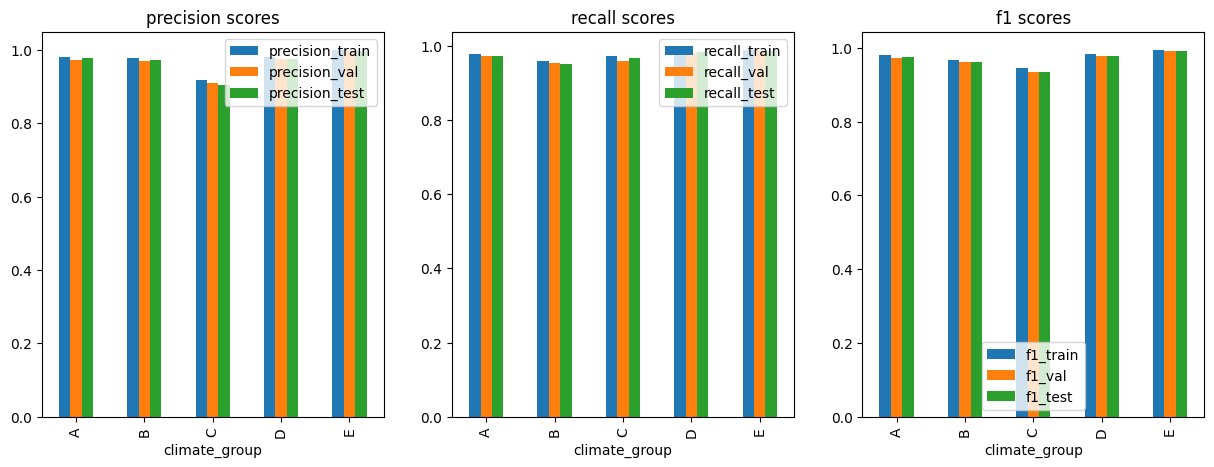

In [63]:
fig1 = matplotlib.pyplot.figure(figsize=(15,5))
ax1 = fig1.add_subplot(1,3,1,title = 'precision scores')
metrics_df.plot.bar(x='climate_group',y=['precision_train','precision_val','precision_test'], ax=ax1)

ax1 = fig1.add_subplot(1,3,2,title = 'recall scores')
metrics_df.plot.bar(x='climate_group',y=['recall_train','recall_val','recall_test'], ax=ax1)

ax1 = fig1.add_subplot(1,3,3,title = 'f1 scores')
metrics_df.plot.bar(x='climate_group',y=['f1_train','f1_val','f1_test'], ax=ax1)

                    

### Confusion matrices
Despite the name, these matrices are intended to enlighten the model developer about the errors in the model. In particular it looks at when the model gets it wrong, what is the distribution of predtictions. Number on the diagonal represent correct predictions. Off the diagonal, the number in a given row and colum tells you how many prediction that were supposed to have the label of the row were actually predicted by the model to the label of the column. 

This is more often used for 2 class classification. A typical example is a classification model which predicts whether or not an impactful weather event will occur. There the key is not to fail to predict an event, but its OK if sometimes there is a *false positive*, that it an event is predicted but doesn't occur.  A confusion matrix for those 2 classes can show us these.

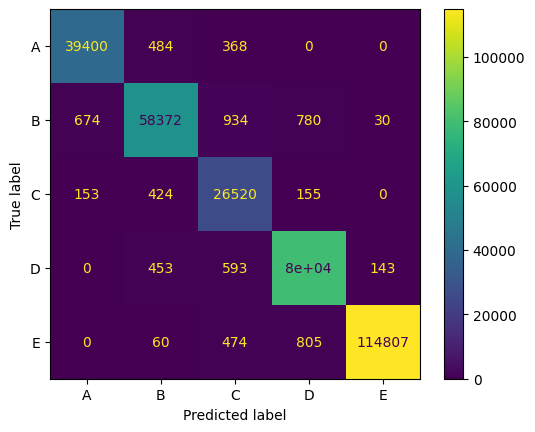

In [45]:
cm_train = sklearn.metrics.ConfusionMatrixDisplay(
    sklearn.metrics.confusion_matrix(target_encoder.inverse_transform(y_train), target_encoder.inverse_transform(y_pred_train)),
    display_labels=stats_dict['target_classes']
)
cm_train.plot()

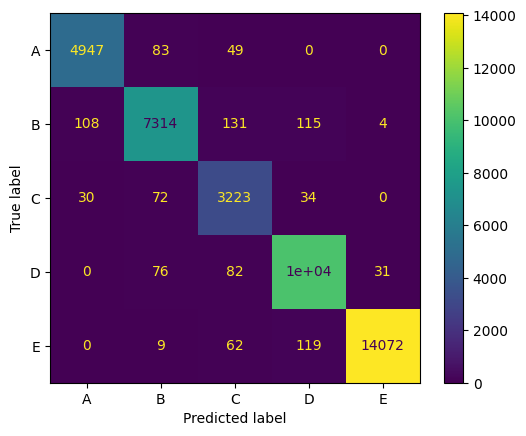

In [47]:
cm_val = sklearn.metrics.ConfusionMatrixDisplay(
    sklearn.metrics.confusion_matrix(target_encoder.inverse_transform(y_val), target_encoder.inverse_transform(y_pred_val)),
    display_labels=stats_dict['target_classes']
)
cm_val.plot()

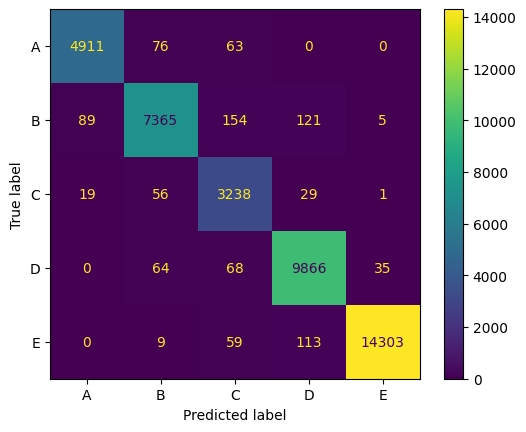

In [48]:
cm_test = sklearn.metrics.ConfusionMatrixDisplay(
    sklearn.metrics.confusion_matrix(target_encoder.inverse_transform(y_test), target_encoder.inverse_transform(y_pred_test)),
    display_labels=stats_dict['target_classes']
)
cm_test.plot()

As we'd expect, when the model gets it wrong, its mostly for a "nearby" class. This is because the climate of D and E are more similar than A and E. We could think about how we can reduce the number of off diaganol predictions and which sort of errors are most important to reduce.

## Exercises

Try to dig deeper into the model performance through the following excercises

### Comparing model performance
Try to load in the stored model for one of the other models trained and compare the results to the decision tree results.

In [46]:
# insert code here

### Trying other metrics
There are many different metrics that can be used for evaluating the skill of a classification model, depending on what is most important in performance. Take a look at some of the other metrics available from sklearn and consider whether any of the metrics migth tell us something different or additional about model performance.

[Metrics and Scoring - sklearn docs](https://scikit-learn.org/stable/modules/model_evaluation.html)

In [46]:
# insert code here

### Data statement
This data used in this notebook is derived from the Koppen-Geiger Climate Cliassfication dataset created by GloH2O.

###     References
- [Climate Zones Dataset](https://www.gloh2o.org/koppen/#:~:text=The%20K%C3%B6ppen%2DGeiger%20climate%20classification%20maps%20are%20high%2Dresolution,Climate%20Sensitivity%20(ECS)%2C%20and%20historical%20warming%20trend)